# Task 0: Decision Tree - F1 score vs max_depth
Dataset: Breast Cancer Wisconsin (Diagnostic), same `data.csv` used across this project.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

## Load and clean the data

In [ ]:
df = pd.read_csv("data.csv")
df = df.drop(columns=[c for c in ["id", "Unnamed: 32"] if c in df.columns])

le = LabelEncoder()
df["diagnosis"] = le.fit_transform(df["diagnosis"])  

X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Loop over max_depth from 3 to 25
For each depth we fit a fresh tree and record F1 on both the train and test splits, to spot overfitting visually and stuff

In [3]:
depth_range = range(3, 26)
train_f1_scores = []
test_f1_scores = []

for depth in depth_range:
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_train, y_train)

    train_pred = clf.predict(X_train)
    test_pred = clf.predict(X_test)

    train_f1_scores.append(f1_score(y_train, train_pred))
    test_f1_scores.append(f1_score(y_test, test_pred))

results = pd.DataFrame({
    "max_depth": list(depth_range),
    "train_f1": train_f1_scores,
    "test_f1": test_f1_scores,
})
results

,max_depth,train_f1,test_f1
0,3,0.954955,0.857143
1,4,0.976331,0.871795
2,5,0.982143,0.886076
3,6,0.991098,0.888889
4,7,0.994083,0.913580
5,8,1.000000,0.904762
6,9,1.000000,0.904762
7,10,1.000000,0.904762
8,11,1.000000,0.904762
9,12,1.000000,0.904762


## Plot 1: Train F1 vs max_depth

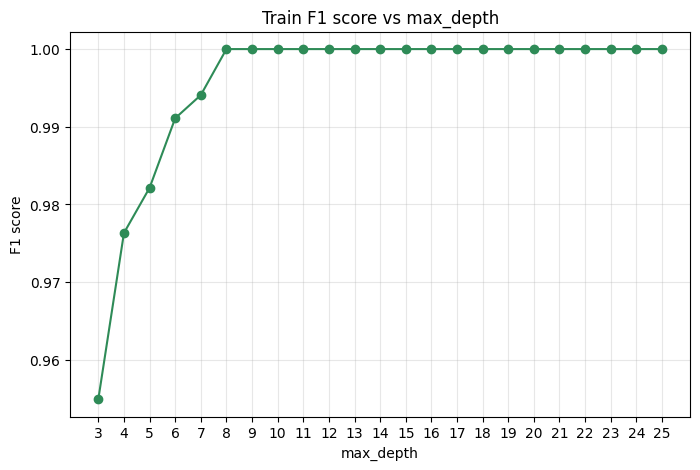

In [4]:
plt.figure(figsize=(8, 5))
plt.plot(depth_range, train_f1_scores, marker="o", color="seagreen")
plt.xlabel("max_depth")
plt.ylabel("F1 score")
plt.title("Train F1 score vs max_depth")
plt.xticks(list(depth_range))
plt.grid(alpha=0.3)
plt.show()

## Plot 2: Test F1 vs max_depth

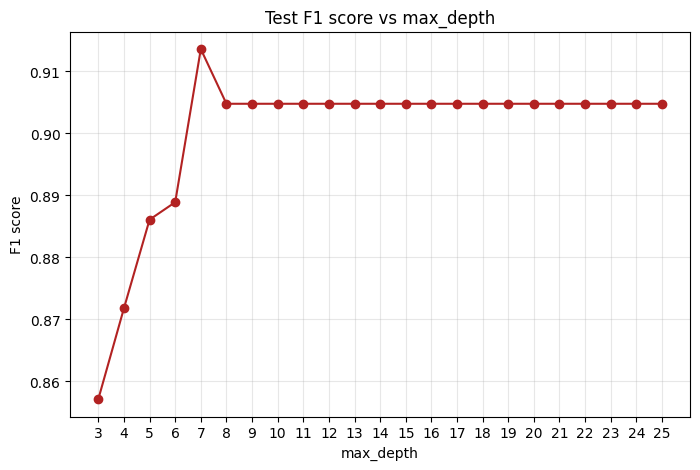

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(depth_range, test_f1_scores, marker="o", color="firebrick")
plt.xlabel("max_depth")
plt.ylabel("F1 score")
plt.title("Test F1 score vs max_depth")
plt.xticks(list(depth_range))
plt.grid(alpha=0.3)
plt.show()

## Both curves together
Overlaying them makes the overfitting gap (if any) much easier to spot than two separate plots.

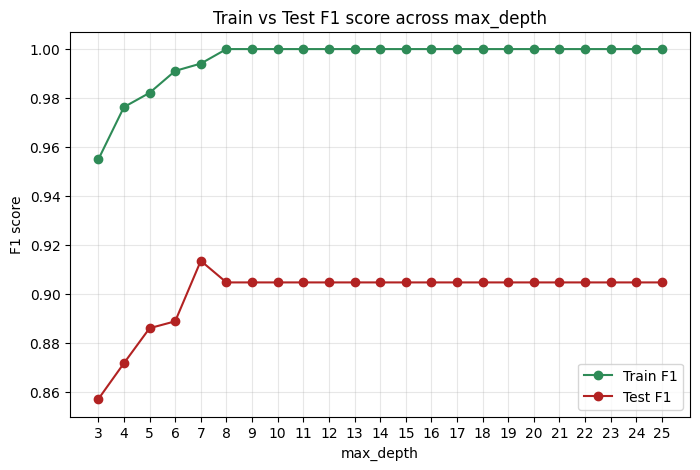

Best max_depth based on test F1: 7


In [6]:
plt.figure(figsize=(8, 5))
plt.plot(depth_range, train_f1_scores, marker="o", label="Train F1", color="seagreen")
plt.plot(depth_range, test_f1_scores, marker="o", label="Test F1", color="firebrick")
plt.xlabel("max_depth")
plt.ylabel("F1 score")
plt.title("Train vs Test F1 score across max_depth")
plt.xticks(list(depth_range))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

best_depth = results.loc[results["test_f1"].idxmax(), "max_depth"]
print("Best max_depth based on test F1:", best_depth)